## Step 3: Network Constraints

## STEP 3A — Build the 24-Bus Network in Python

We will:

- Define buses
- Define transmission lines
- Set uniform reactance
- Compute susceptance
- Visualize the network

In [1]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import numpy

buses = list(range(1, 25))  # 24 buses


# Uniform reactance assumption
x_uniform = 0.002
b_uniform = 1 / x_uniform  # 500

# Transmission line data (From, To, Capacity)
line_data = [
    (1,2,175), (1,3,175), (1,5,350),
    (2,4,175), (2,6,175),
    (3,9,175), (3,24,400),
    (4,9,175),
    (5,10,350),
    (6,10,175),
    (7,8,350),
    (8,9,175), (8,10,175),
    (9,11,400), (9,12,400),
    (10,11,400), (10,12,400),
    (11,13,500), (11,14,500),
    (12,13,500), (12,23,500),
    (13,23,500),
    (14,16,500),
    (15,16,500), (15,21,1000), (15,24,500),
    (16,17,500), (16,19,500),
    (17,18,500), (17,22,500),
    (18,21,1000),
    (19,20,1000),
    (20,23,1000),
    (21,22,500)
]

G = nx.Graph()

# Add buses
G.add_nodes_from(buses)

# Add lines
for (i, j, cap) in line_data:
    G.add_edge(i, j, capacity=cap, susceptance=b_uniform)


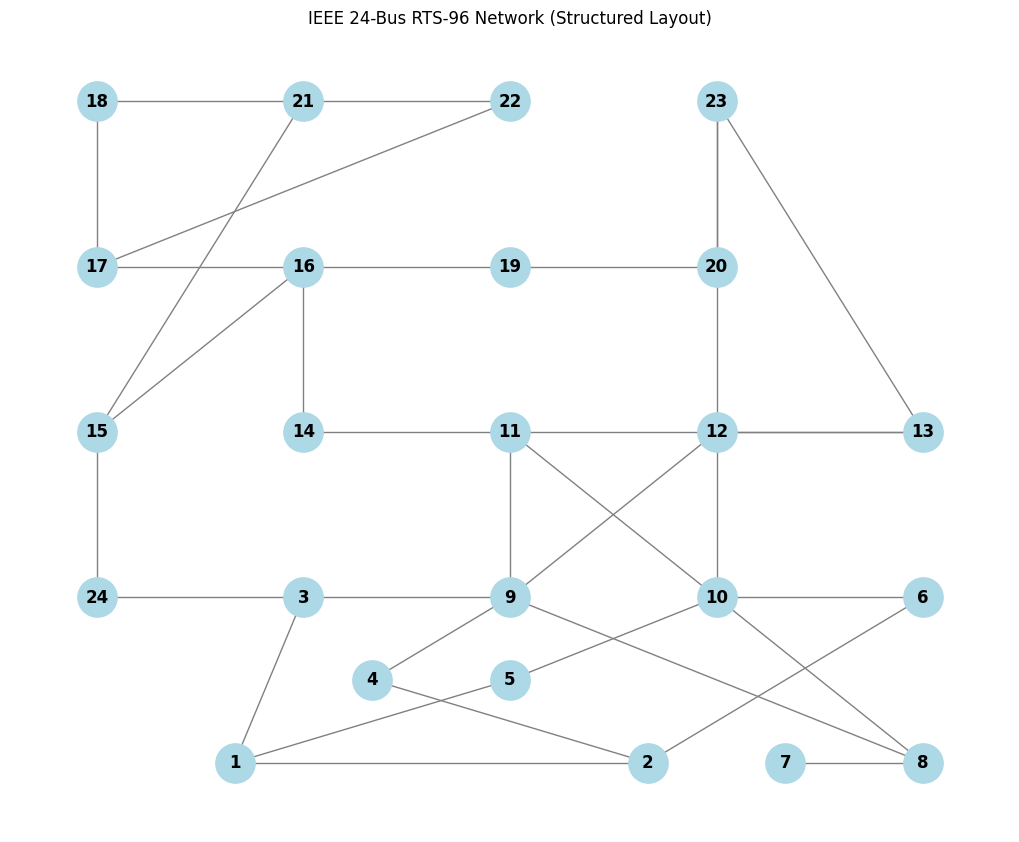

In [2]:
pos = {

    # ----- NORTH -----
    18:(0,4),
    21:(1.5,4),
    22:(3,4),
    23:(4.5,4),

    # ----- UPPER MIDDLE -----
    17:(0,3),
    16:(1.5,3),
    19:(3,3),
    20:(4.5,3),

    # ----- MIDDLE -----
    15:(0,2),
    14:(1.5,2),
    11:(3,2),
    12:(4.5,2),
    13:(6,2),  # slack bus

    # ----- LOWER MIDDLE -----
    24:(0,1),
    3:(1.5,1),
    9:(3,1),
    10:(4.5,1),
    6:(6,1),

    # ----- BOTTOM -----
    1:(1,0),
    4:(2,0.5),
    5:(3,0.5),
    2:(4,0),
    7:(5,0),
    8:(6,0),
}

plt.figure(figsize=(10,8))

nx.draw(G, pos,
        with_labels=True,
        node_size=800,
        node_color='lightblue',
        edge_color='gray',
        font_weight='bold')

plt.title("IEEE 24-Bus RTS-96 Network (Structured Layout)")
plt.axis("off")
plt.show()

## Needed Data from step 1

We keep:
- Generator sets
- Generator capacities
- Generator costs
- Wind availability
- Total demand

In [24]:
# ============================================
# STEP 3 – BASE DATA (FROM STEP 1)
# ============================================

import gurobipy as gp
from gurobipy import GRB
import pandas as pd
import os

# -------------------------
# Sets
# -------------------------

G = range(12)                # Conventional generators
buses = range(1, 25)         # 24 buses

# -------------------------
# Generator Parameters
# -------------------------

P_max = {
    0: 152, 1: 152, 2: 350, 3: 591, 4: 60, 5: 155,
    6: 155, 7: 400, 8: 400, 9: 300, 10: 310, 11: 350
}

C = {
    0: 13.32, 1: 13.32, 2: 20.70, 3: 20.93, 4: 26.11,
    5: 10.52, 6: 10.52, 7: 6.02, 8: 5.47, 9: 0.00,
    10: 10.52, 11: 10.89
}

# -------------------------
# Demand
# -------------------------

D_t = 2650.5      # Total system demand

# ============================================
# WIND DATA IMPORT
# ============================================
wind_file = os.path.join("data", "processed", "wind_available_power_6_nodes_MW.csv")

wind_data = pd.read_csv(wind_file)

# Choose specific hour (same hour used in Step 1)
hour_star = 18

node_map = {
    1: "wind_3",
    2: "wind_5",
    3: "wind_7",
    4: "wind_16",
    5: "wind_21",
    6: "wind_23"
}

P_w_bar = {w: wind_data.loc[hour_star, node_map[w]] for w in node_map}

## 3B.1 Generator-to-Bus Mapping

## 3B.2 Generator and Demand Distribution

We now convert total demand → nodal demand.

In [25]:
# ============================================
# STEP 3 – Generator & Wind Location
# ============================================

# Generator-to-bus mapping (RTS-96 consistent)

gen_bus = {
    0: 1,
    1: 2,
    2: 7,
    3: 13,
    4: 15,
    5: 15,
    6: 16,
    7: 18,
    8: 21,
    9: 22,
    10: 23,
    11: 23
}


# Wind location
W = [1,2,3,4,5,6]
wind_bus = {
    1: 3,
    2: 5,
    3: 7,
    4: 16,
    5: 21,
    6: 23
}

In [26]:
# ============================================
# STEP 3 – Exact Load Distribution
# ============================================

load_percent = {
    1:3.8, 2:3.4, 3:6.3, 4:2.6, 5:2.5,
    6:4.8, 7:4.4, 8:6.0, 9:6.1, 10:6.8,
    13:9.3, 14:6.8, 15:11.1, 16:3.5,
    18:11.7, 19:6.4, 20:4.5
}

# Convert to fractions
load_share = {n: load_percent[n]/100 for n in load_percent}

# Check total ≈ 1
print("Sum of load shares:", sum(load_share.values()))

# Build nodal demand
D_bus = {
    n: D_t * load_share.get(n, 0)
    for n in buses
}

# Build nodal utility
U_bus = {
    n: 8 + 200 * load_share[n]   # ~30–75 €/MWh
    for n in load_share
}

Sum of load shares: 1.0


## Build the model!!!!

In [27]:
# ============================================
# STEP 3B – NODAL DC MARKET CLEARING
# ============================================

model = gp.Model("Nodal_DC_OPF")

# -------------------------
# Variables
# -------------------------

# Generation
p_i = model.addVars(G, lb=0,
                    ub=[P_max[i] for i in G],
                    name="p_i")

# Wind
p_w = model.addVars(
    W,
    lb=0,
    ub=[P_w_bar[w] for w in W],
    name="p_w"
)

# Demand at bus n
d_n = model.addVars(buses, lb=0, name="d_n")

# Voltage angles
theta = model.addVars(buses, lb=-GRB.INFINITY, name="theta")

# Line flows
f = {}
for (i, j, cap) in line_data:
    f[i, j] = model.addVar(lb=-cap, ub=cap, name=f"f_{i}_{j}")

DC Flow Constraints

In [28]:
b = 500  # uniform susceptance

for (i, j, cap) in line_data:
    model.addConstr(
        f[i, j] == b * (theta[i] - theta[j]),
        name=f"dcflow_{i}_{j}"
    )

Nodal Power Balance

In [29]:
balance = {}

for n in buses:

    gen_sum = gp.quicksum(
        p_i[i] for i in G if gen_bus[i] == n
    )

    wind_term = gp.quicksum(
        p_w[w] for w in W if wind_bus[w] == n
    )

    flow_out = gp.quicksum(
        f[n, j] for (i, j, cap) in line_data if i == n
    )

    flow_in = gp.quicksum(
        f[i, n] for (i, j, cap) in line_data if j == n
    )

    balance[n] = model.addConstr(
        gen_sum + wind_term - d_n[n]
        == flow_out - flow_in,
        name=f"balance_{n}"
    )

    # demand cap
    model.addConstr(d_n[n] <= D_bus[n])

Slack Bus here

In [30]:
model.addConstr(theta[13] == 0, name="slack_bus")

<gurobi.Constr *Awaiting Model Update*>

Optimize by only accounting for costs as demand and Utility are steady

In [31]:
model.setObjective(
    gp.quicksum(C[i] * p_i[i] for i in G)
    -
    gp.quicksum(U_bus.get(n, 0) * d_n[n] for n in buses),
    GRB.MINIMIZE
)

model.optimize()

Gurobi Optimizer version 13.0.1 build v13.0.1rc0 (win64 - Windows 11+.0 (26200.2))

CPU model: AMD Ryzen 5 4600H with Radeon Graphics, instruction set [SSE2|AVX|AVX2]
Thread count: 6 physical cores, 12 logical processors, using up to 12 threads

Optimize a model with 83 rows, 100 columns and 237 nonzeros (Min)
Model fingerprint: 0xd3225f34
Model has 28 linear objective coefficients
Coefficient statistics:
  Matrix range     [1e+00, 5e+02]
  Objective range  [5e+00, 3e+01]
  Bounds range     [3e+01, 1e+03]
  RHS range        [7e+01, 3e+02]

Presolve removed 52 rows and 35 columns
Presolve time: 0.01s
Presolved: 31 rows, 65 columns, 152 nonzeros

Iteration    Objective       Primal Inf.    Dual Inf.      Time
       0   -5.8673588e+04   1.889887e+03   0.000000e+00      0s
      24   -4.1179865e+04   0.000000e+00   0.000000e+00      0s

Solved in 24 iterations and 0.01 seconds (0.00 work units)
Optimal objective -4.117986452e+04


## Extract the results

Extract Nodal prices and conjested lines

In [32]:
lambda_n = {}

print("\n========== NODAL PRICES ==========\n")

for n in buses:
    lambda_n[n] = balance[n].Pi
    print(f"Bus {n}: λ = {lambda_n[n]:.2f} €/MWh")



print("\n========== CONGESTED LINES ==========\n")

for (i, j, cap) in line_data:
    if abs(f[i, j].X) > 0.999 * cap:
        print(f"Line {i}-{j} congested")


========== NODAL PRICES ==========

Bus 1: λ = 13.32 €/MWh
Bus 2: λ = 13.32 €/MWh
Bus 3: λ = 13.32 €/MWh
Bus 4: λ = 13.32 €/MWh
Bus 5: λ = 13.32 €/MWh
Bus 6: λ = 13.32 €/MWh
Bus 7: λ = 13.32 €/MWh
Bus 8: λ = 13.32 €/MWh
Bus 9: λ = 13.32 €/MWh
Bus 10: λ = 13.32 €/MWh
Bus 11: λ = 13.32 €/MWh
Bus 12: λ = 13.32 €/MWh
Bus 13: λ = 13.32 €/MWh
Bus 14: λ = 13.32 €/MWh
Bus 15: λ = 13.32 €/MWh
Bus 16: λ = 13.32 €/MWh
Bus 17: λ = 13.32 €/MWh
Bus 18: λ = 13.32 €/MWh
Bus 19: λ = 13.32 €/MWh
Bus 20: λ = 13.32 €/MWh
Bus 21: λ = 13.32 €/MWh
Bus 22: λ = 13.32 €/MWh
Bus 23: λ = 13.32 €/MWh
Bus 24: λ = 13.32 €/MWh

========== CONGESTED LINES ==========



In [33]:
# ============================================
# STEP 3B – RESULTS & INTERPRETATION
# ============================================

if model.status == GRB.OPTIMAL:

    print("\n========== NODAL RESULTS ==========\n")

    # -------------------------
    # Total generation cost
    # -------------------------
    total_cost = sum(C[i] * p_i[i].X for i in G)
    print(f"Total generation cost: {total_cost:.2f} €")

    # -------------------------
    # Social welfare
    # -------------------------
    total_utility = sum(D_bus[n] * 100 for n in buses)  # U_d = 100
    social_welfare = total_utility - total_cost
    print(f"Social welfare: {social_welfare:.2f} €")

    # -------------------------
    # Nodal prices
    # -------------------------
    print("\nNodal Prices (€/MWh):")
    lambda_n = {}

    for n in buses:
        lambda_n[n] = balance[n].Pi
        print(f"Bus {n}: {lambda_n[n]:.2f}")

    # -------------------------
    # Check congestion
    # -------------------------
    print("\nCongested Lines:")
    congested = False

    for (i, j, cap) in line_data:
        if abs(f[i, j].X) > 0.999 * cap:
            print(f"Line {i}-{j} at capacity")
            congested = True

    if not congested:
        print("No lines congested.")


========== NODAL RESULTS ==========

Total generation cost: 15722.66 €
Social welfare: 249327.34 €

Nodal Prices (€/MWh):
Bus 1: 13.32
Bus 2: 13.32
Bus 3: 13.32
Bus 4: 13.32
Bus 5: 13.32
Bus 6: 13.32
Bus 7: 13.32
Bus 8: 13.32
Bus 9: 13.32
Bus 10: 13.32
Bus 11: 13.32
Bus 12: 13.32
Bus 13: 13.32
Bus 14: 13.32
Bus 15: 13.32
Bus 16: 13.32
Bus 17: 13.32
Bus 18: 13.32
Bus 19: 13.32
Bus 20: 13.32
Bus 21: 13.32
Bus 22: 13.32
Bus 23: 13.32
Bus 24: 13.32

Congested Lines:
No lines congested.


## Do congestion Rent

In [34]:
# --------------------------------------------
# Congestion Rent
# --------------------------------------------

congestion_rent = 0

for (i, j, cap) in line_data:
    flow = f[i, j].X
    
    # Always use correct direction
    if flow >= 0:
        congestion_rent += (lambda_n[j] - lambda_n[i]) * flow
    else:
        congestion_rent += (lambda_n[i] - lambda_n[j]) * (-flow)

print(f"Congestion rent: {congestion_rent:.2f} €")

Congestion rent: -0.00 €


## Visualization

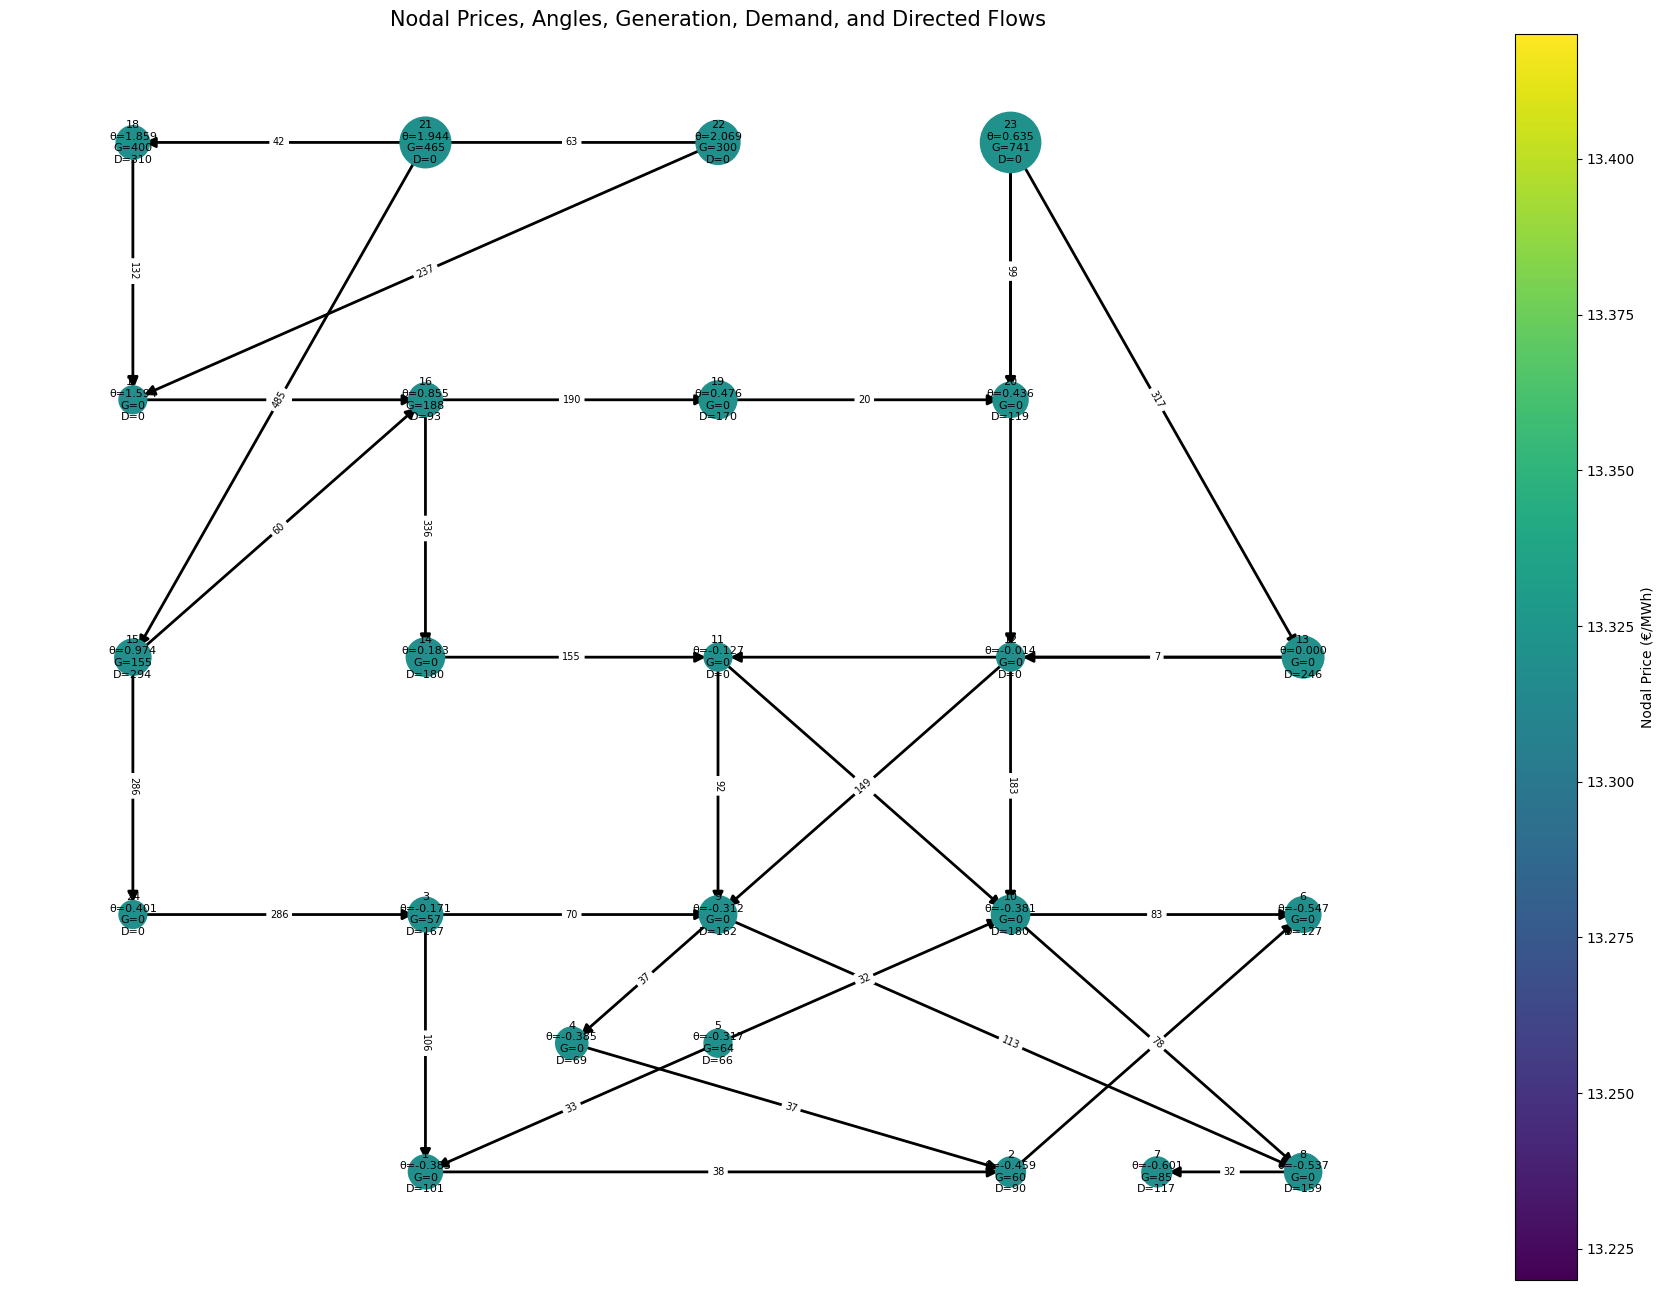

In [35]:
# ============================================
# FULL PROFESSIONAL NETWORK VISUALIZATION
# (Price, Theta, Generation, Demand, Flows)
# ============================================

import networkx as nx
import matplotlib.pyplot as plt
import numpy as np

# -------------------------
# Build directed graph for arrows
# -------------------------
G_vis = nx.DiGraph()
G_vis.add_nodes_from(range(1, 25))

for (i, j, cap) in line_data:
    flow = f[i, j].X
    if flow >= 0:
        G_vis.add_edge(i, j, flow=flow, capacity=cap)
    else:
        G_vis.add_edge(j, i, flow=abs(flow), capacity=cap)

# -------------------------
# Structured Layout (stretched)
# -------------------------
pos = {
    18:(0,4), 21:(2,4), 22:(4,4), 23:(6,4),
    17:(0,3), 16:(2,3), 19:(4,3), 20:(6,3),
    15:(0,2), 14:(2,2), 11:(4,2), 12:(6,2), 13:(8,2),
    24:(0,1), 3:(2,1), 9:(4,1), 10:(6,1), 6:(8,1),
    1:(2,0), 4:(3,0.5), 5:(4,0.5), 2:(6,0), 7:(7,0), 8:(8,0),
}

# -------------------------
# Prices (fix scale if equal)
# -------------------------
prices = np.array([lambda_n[n] for n in G_vis.nodes()])
p_min = prices.min()
p_max = prices.max()

if abs(p_max - p_min) < 1e-6:
    p_min -= 0.1
    p_max += 0.1

# -------------------------
# Node sizes (injection magnitude)
# -------------------------
node_sizes = []
for n in G_vis.nodes():
    gen = sum(p_i[i].X for i in G if gen_bus[i] == n)
    wind = sum(p_w[w].X for w in W if wind_bus[w] == n)
    demand = D_bus[n]
    net = abs(gen + wind - demand)
    node_sizes.append(400 + 2*net)

# -------------------------
# Plot
# -------------------------
plt.figure(figsize=(18,13))

# Nodes
nodes = nx.draw_networkx_nodes(
    G_vis,
    pos,
    node_color=prices,
    cmap="viridis",
    vmin=p_min,
    vmax=p_max,
    node_size=node_sizes
)

# Edges with arrows
nx.draw_networkx_edges(
    G_vis,
    pos,
    arrows=True,
    arrowstyle='-|>',
    arrowsize=15,
    width=2
)

# -------------------------
# Node Labels (Bus, Theta, Generation, Demand)
# -------------------------
labels = {}

for n in G_vis.nodes():

    gen = sum(p_i[i].X for i in G if gen_bus[i] == n)
    wind = sum(p_w[w].X for w in W if wind_bus[w] == n)
    total_gen = gen + wind
    demand = D_bus[n]

    labels[n] = (
        f"{n}\n"
        f"θ={theta[n].X:.3f}\n"
        f"G={total_gen:.0f}\n"
        f"D={demand:.0f}"
    )

nx.draw_networkx_labels(G_vis, pos, labels=labels, font_size=8)

# -------------------------
# Flow Labels
# -------------------------
edge_labels = {
    (u,v): f"{data['flow']:.0f}"
    for u,v,data in G_vis.edges(data=True)
}

nx.draw_networkx_edge_labels(
    G_vis,
    pos,
    edge_labels=edge_labels,
    font_size=7
)

# Colorbar
cbar = plt.colorbar(nodes)
cbar.set_label("Nodal Price (€/MWh)")

plt.title("Nodal Prices, Angles, Generation, Demand, and Directed Flows", fontsize=15)
plt.axis("off")
plt.tight_layout()
plt.show()

In [36]:
for (i,j,cap) in line_data:
    print(f"{i}-{j}: {f[i,j].X:.2f}")

1-2: 37.93
1-3: -105.88
1-5: -32.77
2-4: -36.77
2-6: 44.10
3-9: 70.28
3-24: -286.29
4-9: -36.77
5-10: 31.68
6-10: -83.13
7-8: -31.99
8-9: -112.76
8-10: -78.26
9-11: -92.26
9-12: -148.67
10-11: -126.77
10-12: -183.17
11-13: -63.64
11-14: -155.39
12-13: -7.23
12-23: -324.61
13-23: -317.37
14-16: -335.62
15-16: 59.60
15-21: -485.09
15-24: 286.29
16-17: -369.82
16-19: 189.51
17-18: -132.38
17-22: -237.44
18-21: -42.49
19-20: 19.88
20-23: -99.39
21-22: -62.56


## 3B.3 Sensitivity analysis (line capacity)

from unittest import case


Goal: change the capacity of one transmission line and see how it affects:
- nodal prices (LMPs)
- congestion (which lines bind)
- dispatch cost / social welfare

We pick the **most loaded line in the base case** (highest |flow|/capacity) and scale its capacity.

In [37]:
# --- Sensitivity setup: pick a "critical" line from the BASE solution ---

# Make sure the base model has been solved and f,line_data exist
assert "f" in globals() and "line_data" in globals(), "Run the base nodal model first (so f and line_data exist)."

loading = []
for (i, j, cap) in line_data:
    flow_ij = float(f[i, j].X)
    loading.append((abs(flow_ij) / cap if cap > 0 else 0.0, i, j, cap, flow_ij))

loading.sort(reverse=True)
top = loading[0]
ratio, i_star, j_star, cap_star, flow_star = top

print("Most loaded line in base case:")
print(f"  line {i_star}-{j_star}: flow={flow_star:.2f} MW, cap={cap_star:.2f} MW, loading={ratio*100:.1f}%")


Most loaded line in base case:
  line 16-17: flow=-369.82 MW, cap=500.00 MW, loading=74.0%


In [38]:
# --- Helper: solve nodal DC-OPF with a modified line_data list ---

import gurobipy as gp
from gurobipy import GRB

def solve_nodal_dc(line_data_local, verbose=False):
    # Uses globals defined earlier in the notebook:
    # buses, G, P_max, C, gen_bus, wind_bus, P_w_bar, D_bus, b (susceptance), slack bus=13
    required = ["buses","G","W","P_max","C","gen_bus","wind_bus","P_w_bar","D_bus"]
    for name in required:
        assert name in globals(), f"Missing global '{name}'. Run the earlier cells first."

    b_val = globals().get("b", None)
    assert b_val is not None, "Missing susceptance 'b'."

    m = gp.Model("Nodal_DC_OPF_sens")
    if not verbose:
        m.Params.OutputFlag = 0

    # Variables
    p = m.addVars(G, lb=0, ub=[P_max[i] for i in G], name="p")
    pw = m.addVars(
        W,
        lb=0,
        ub=[P_w_bar[w] for w in W],
        name="p_w"
    )
    theta = m.addVars(buses, lb=-GRB.INFINITY, name="theta")

    fvar = {}
    for (i, j, cap) in line_data_local:
        fvar[i, j] = m.addVar(lb=-cap, ub=cap, name=f"f_{i}_{j}")

    # DC flow constraints
    for (i, j, cap) in line_data_local:
        m.addConstr(fvar[i, j] == b_val * (theta[i] - theta[j]), name=f"dcflow_{i}_{j}")

    # Nodal balances (dual = nodal price)
    balance = {}
    for n in buses:
        gen_sum = gp.quicksum(p[i] for i in G if gen_bus[i] == n)
        wind_term = gp.quicksum(pw[w] for w in W if wind_bus[w] == n)
        demand = D_bus.get(n, 0.0)

        flow_out = gp.quicksum(fvar[n, j] for (n2, j, cap) in line_data_local if n2 == n)
        flow_in  = gp.quicksum(fvar[i, n] for (i, n2, cap) in line_data_local if n2 == n)

        balance[n] = m.addConstr(gen_sum + wind_term - demand == flow_out - flow_in, name=f"balance_{n}")

    # Slack bus
    m.addConstr(theta[13] == 0, name="slack_bus")

    # Objective (min cost)
    m.setObjective(gp.quicksum(C[i] * p[i] for i in G), GRB.MINIMIZE)
    m.optimize()

    assert m.status == GRB.OPTIMAL, f"Model not optimal, status={m.status}"

    # Extract results
    lambda_n = {n: float(balance[n].Pi) for n in buses}
    flows = {(i, j): float(fvar[i, j].X) for (i, j, cap) in line_data_local}
    congested = []
    for (i, j, cap) in line_data_local:
        if abs(flows[i, j]) >= 0.999 * cap:
            congested.append((i, j))

    total_cost = sum(C[i] * float(p[i].X) for i in G)
    total_utility = sum(D_bus.get(n, 0.0) * 100.0 for n in buses)  # U_d = 100 in this assignment setup
    welfare = total_utility - total_cost

    return {
        "lambda_n": lambda_n,
        "flows": flows,
        "congested_lines": congested,
        "total_cost": total_cost,
        "welfare": welfare,
        "p": {i: float(p[i].X) for i in G},
        "p_w": {w: float(pw[w].X) for w in W},
    }


In [39]:
# --- Run sensitivity: scale the capacity of the selected line ---

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

scales = [1.0, 0.75, 0.7,0.65, 0.6, 0.55, 0.5, 0.4, 0.3, 0.25, 0.10, 0.05]

rows = []
for s in scales:
    # modify ONLY the selected line (i_star, j_star)
    line_data_mod = []
    for (i, j, cap) in line_data:
        if (i == i_star and j == j_star) or (i == j_star and j == i_star):
            line_data_mod.append((i, j, cap * s))
        else:
            line_data_mod.append((i, j, cap))

    out = solve_nodal_dc(line_data_mod, verbose=False)

    lam = np.array(list(out["lambda_n"].values()))
    rows.append({
        "cap_scale": s,
        "cap_star": cap_star * s,
        "price_min": float(lam.min()),
        "price_max": float(lam.max()),
        "price_spread": float(lam.max() - lam.min()),
        "n_congested": len(out["congested_lines"]),
        "total_cost": out["total_cost"],
        "welfare": out["welfare"],
        "congested_lines": out["congested_lines"],
    })

df_sens = pd.DataFrame(rows)
df_sens


,cap_scale,cap_star,price_min,price_max,price_spread,n_congested,total_cost,welfare,congested_lines
0,1.00,500.0,13.320000,13.320000,1.065814e-14,0,17523.197440,247526.802560,[]
1,0.75,375.0,13.320000,13.320000,1.065814e-14,0,17523.197440,247526.802560,[]
2,0.70,350.0,4.147730,14.669518,1.052179e+01,1,17815.019206,247234.980794,"[(16, 17)]"
3,0.65,325.0,4.147730,14.669518,1.052179e+01,1,18171.677408,246878.322592,"[(16, 17)]"
4,0.60,300.0,2.422508,22.639699,2.021719e+01,1,18719.252626,246330.747374,"[(16, 17)]"
5,0.55,275.0,2.422508,22.639699,2.021719e+01,1,19404.556974,245645.443026,"[(16, 17)]"
6,0.50,250.0,2.422508,22.639699,2.021719e+01,1,20089.861322,244960.138678,"[(16, 17)]"
7,0.40,200.0,2.422508,22.639699,2.021719e+01,1,21460.470017,243589.529983,"[(16, 17)]"
8,0.30,150.0,-4.362872,23.266524,2.762940e+01,1,22895.500953,242154.499047,"[(16, 17)]"
9,0.25,125.0,-4.362872,23.266524,2.762940e+01,1,23832.057628,241217.942372,"[(16, 17)]"


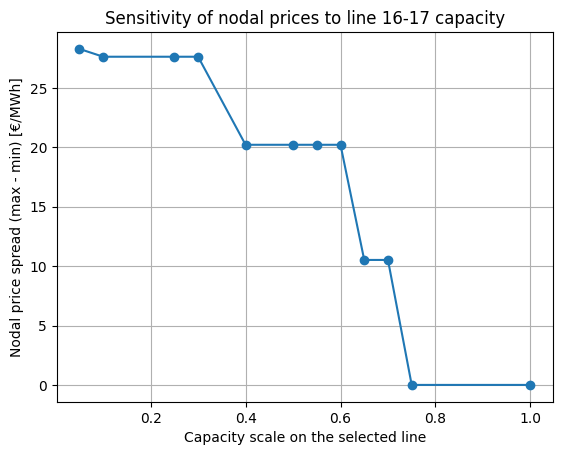

In [40]:
# Plot how price spread changes when we tighten the selected line

plt.figure()
plt.plot(df_sens["cap_scale"], df_sens["price_spread"], marker="o")
plt.xlabel("Capacity scale on the selected line")
plt.ylabel("Nodal price spread (max - min) [€/MWh]")
plt.title(f"Sensitivity of nodal prices to line {i_star}-{j_star} capacity")
plt.grid(True)
plt.show()


In [41]:
# ============================================
# SCENARIO: FORCED CONGESTION (MULTIPLE LINES)
# ============================================

line_mods = {
    (15,21): 400,
    (14,16): 250,
    (13,23): 250
}

line_data_mod = []

for (i, j, cap) in line_data:
    
    if (i, j) in line_mods:
        line_data_mod.append((i, j, line_mods[(i, j)]))
    
    elif (j, i) in line_mods:
        line_data_mod.append((i, j, line_mods[(j, i)]))
    
    else:
        line_data_mod.append((i, j, cap))


# Solve new scenario
out_cong = solve_nodal_dc(line_data_mod)

# -------------------------
# PRINT RESULTS
# -------------------------
print("\n===== FORCED CONGESTION SCENARIO =====\n")

print("Total cost:", round(out_cong["total_cost"],2))
print("Social welfare:", round(out_cong["welfare"],2))

print("\nNodal prices:")
for n in buses:
    print(f"Bus {n}: {out_cong['lambda_n'][n]:.2f}")

print("\nCongested lines:")
for line in out_cong["congested_lines"]:
    print(f"{line[0]}-{line[1]}")


===== FORCED CONGESTION SCENARIO =====

Total cost: 20123.67
Social welfare: 244926.33

Nodal prices:
Bus 1: 17.29
Bus 2: 17.50
Bus 3: 16.83
Bus 4: 17.57
Bus 5: 17.54
Bus 6: 17.65
Bus 7: 17.71
Bus 8: 17.71
Bus 9: 17.64
Bus 10: 17.79
Bus 11: 19.25
Bus 12: 16.81
Bus 13: 20.93
Bus 14: 20.63
Bus 15: 14.31
Bus 16: 10.52
Bus 17: 7.99
Bus 18: 6.73
Bus 19: 10.64
Bus 20: 10.77
Bus 21: 5.47
Bus 22: 6.73
Bus 23: 10.89
Bus 24: 15.57

Congested lines:
13-23
14-16
15-21


In [42]:
print("\nPrice spread comparison:")
print("Base:", max(lambda_n.values()) - min(lambda_n.values()))
print("Constrained:", max(out_cong["lambda_n"].values()) - min(out_cong["lambda_n"].values()))


Price spread comparison:
Base: 2.4868995751603507e-14
Constrained: 15.46


In [44]:
congestion_rent = 0

lambda_cong = out_cong["lambda_n"]
flows_cong = out_cong["flows"]

congestion_rent = sum(
    abs(flows_cong[i,j]) * abs(lambda_cong[i] - lambda_cong[j])
    for (i,j,cap) in line_data_mod
)

print(f"Congestion rent (constrained case): {congestion_rent:.2f} €")

Congestion rent (constrained case): 13671.96 €
